PROJECT-HOUSE PRICE PREDICTION

Importing libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", None)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving house_price_dataset_india_12k.csv to house_price_dataset_india_12k.csv


Loading dataset

In [31]:
df = pd.read_csv("house_price_dataset_india_12k.csv")

Inspecting Data And Statistical Analysis


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   House_ID                   12000 non-null  int64  
 1   City                       12000 non-null  object 
 2   Locality_Tier              12000 non-null  object 
 3   BHK                        12000 non-null  int64  
 4   Bathrooms                  12000 non-null  int64  
 5   Super_Area_sqft            12000 non-null  float64
 6   Carpet_Area_sqft           12000 non-null  float64
 7   Floor_No                   12000 non-null  int64  
 8   Total_Floors               12000 non-null  int64  
 9   Property_Age_years         12000 non-null  int64  
 10  Parking                    12000 non-null  int64  
 11  Furnishing                 12000 non-null  object 
 12  Lift                       12000 non-null  int64  
 13  Gated_Society              12000 non-null  int

,House_ID,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000
mean,6000.50000,2.304167,2.536083,1018.260342,763.563383,7.599000,15.232667,8.615917,0.640083,0.924167,0.588667,2.153820,14.101654,2.807817,3.059477,41.756825,1.020406e+07,9689.409667
std,3464.24595,0.934909,1.102482,379.974189,291.095491,5.685352,5.707604,5.374815,0.479996,0.264742,0.492096,1.817501,7.149948,1.352786,1.507851,13.716940,6.707595e+06,4279.861543
min,1.00000,1.000000,1.000000,350.000000,250.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.500000,0.200000,0.300000,5.000000,1.356119e+06,2480.000000
25%,3000.75000,2.000000,2.000000,781.800000,569.700000,3.000000,11.000000,4.000000,0.000000,1.000000,0.000000,0.410000,9.000000,1.840000,1.990000,32.200000,5.586925e+06,6562.750000
50%,6000.50000,2.000000,2.000000,950.500000,715.550000,7.000000,15.000000,8.000000,1.000000,1.000000,1.000000,1.830000,14.010000,2.800000,3.000000,41.800000,8.558740e+06,8763.000000
75%,9000.25000,3.000000,3.000000,1226.300000,915.200000,11.000000,19.000000,12.000000,1.000000,1.000000,1.000000,3.340000,19.000000,3.760000,4.080000,51.400000,1.304248e+07,11980.000000
max,12000.00000,5.000000,7.000000,3010.400000,2285.900000,32.000000,38.000000,33.000000,1.000000,1.000000,1.000000,11.600000,39.800000,8.710000,8.810000,85.400000,5.755283e+07,22626.000000


Checking for a missing value in the dataset

In [ ]:
print(df.isnull().sum())

House_ID                     0
City                         0
Locality_Tier                0
BHK                          0
Bathrooms                    0
Super_Area_sqft              0
Carpet_Area_sqft             0
Floor_No                     0
Total_Floors                 0
Property_Age_years           0
Parking                      0
Furnishing                   0
Lift                         0
Gated_Society                0
Distance_to_Metro_km         0
Distance_to_CityCenter_km    0
Nearby_School_km             0
Nearby_Hospital_km           0
Crime_Rate_Index             0
Market_Price_INR             0
Price_per_sqft_INR           0
dtype: int64


Checking for duplicate values in the dataset

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Checking for the datatypes

In [ ]:
print(df.dtypes)

House_ID                       int64
City                          object
Locality_Tier                 object
BHK                            int64
Bathrooms                      int64
Super_Area_sqft              float64
Carpet_Area_sqft             float64
Floor_No                       int64
Total_Floors                   int64
Property_Age_years             int64
Parking                        int64
Furnishing                    object
Lift                           int64
Gated_Society                  int64
Distance_to_Metro_km         float64
Distance_to_CityCenter_km    float64
Nearby_School_km             float64
Nearby_Hospital_km           float64
Crime_Rate_Index             float64
Market_Price_INR               int64
Price_per_sqft_INR             int64
dtype: object


 Removing leading and trailing spaces from text columns

In [ ]:

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].str.strip()

print("Extra spaces removed.")
# Verification
for col in categorical_cols:
    if (df[col] != df[col].str.strip()).any():
        print(f"Extra spaces found in {col}")
    else:
        print(f"No extra spaces in {col}")

Extra spaces removed.
No extra spaces in City
No extra spaces in Locality_Tier
No extra spaces in Furnishing


Standardizing the text

In [ ]:

for col in categorical_cols:
    df[col] = df[col].str.title()

print("Text standardized.")

Text standardized.


Saving the new Cleaned File

In [30]:
df.to_csv("cleaned_house_price_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [ ]:
# Verify the saved file
import os
print(os.path.exists("cleaned_house_price_dataset.csv"))


True


EDA


1.distribution of House Prices

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Price_per_sqft_INR'], bins=30, edgecolor='black')
plt.xlabel('Price per Square Foot (INR)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.savefig("pricepersqft.png")
plt.show()

: 

Observation: Most properties have a price per square foot between ₹5,000 and ₹12,000. The distribution is positively skewed, indicating that fewer properties have significantly higher prices.

2. City wise distribution

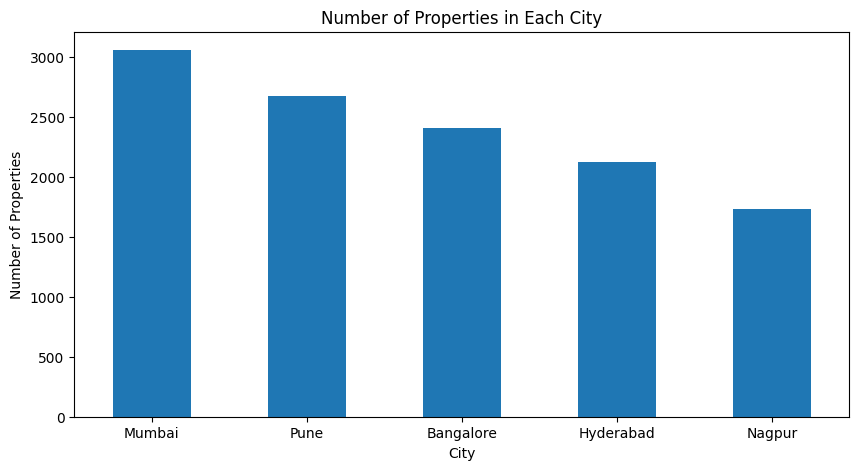

In [ ]:
plt.figure(figsize=(10, 5))
df['City'].value_counts().plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Number of Properties')
plt.title('Number of Properties in Each City')
plt.xticks(rotation=0)
plt.show()

Observation: Mumbai has the highest number of properties in the dataset, followed by Pune and Bangalore. Nagpur has the lowest number of properties among the five cities.

3. BHK Distribution

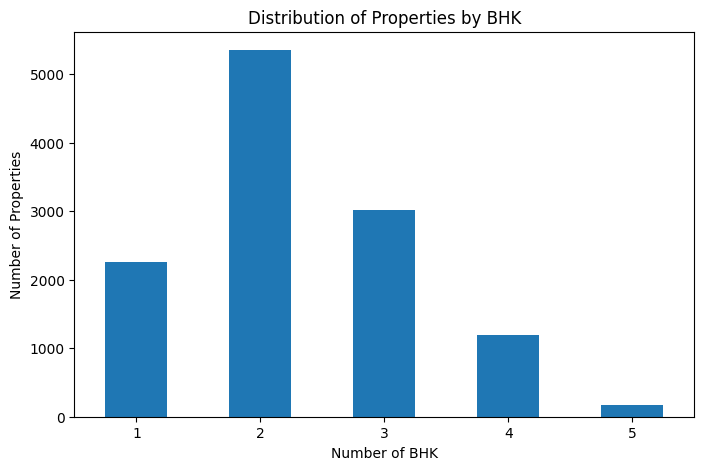

In [ ]:
plt.figure(figsize=(8, 5))
df['BHK'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of BHK')
plt.ylabel('Number of Properties')
plt.title('Distribution of Properties by BHK')
plt.xticks(rotation=0)
plt.show()

Observation: 2 BHK properties are the most common in the dataset, followed by 3 BHK and 1 BHK properties. The number of properties decreases significantly for 4 BHK and 5 BHK configurations.

4. City vs House Price

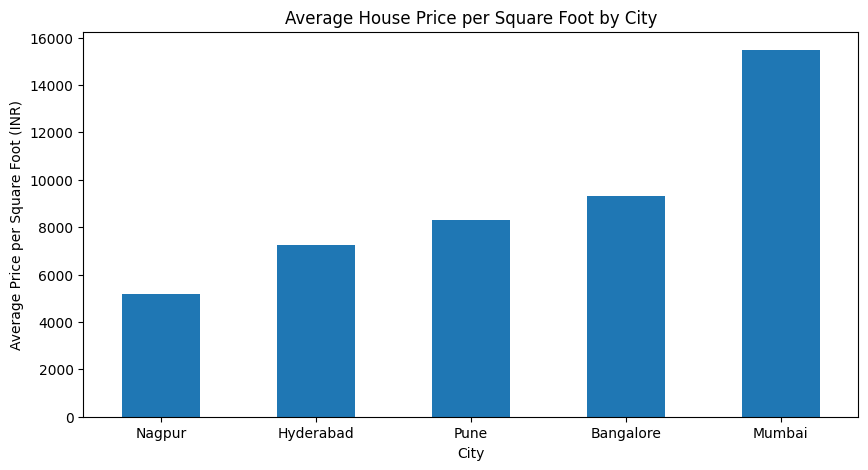

In [ ]:
average_price_city = df.groupby('City')['Price_per_sqft_INR'].mean().sort_values()

plt.figure(figsize=(10, 5))
average_price_city.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Average Price per Square Foot (INR)')
plt.title('Average House Price per Square Foot by City')
plt.xticks(rotation=0)
plt.show()

Observation: Mumbai has the highest average price per square foot, followed by Bangalore, Pune, Hyderabad, and Nagpur. This indicates that city location has a significant influence on property prices.

5. BHK vs Average Price

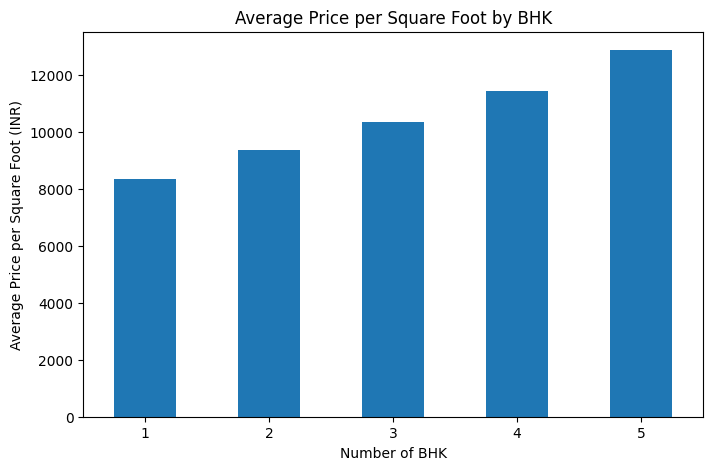

In [ ]:
average_price_bhk = df.groupby('BHK')['Price_per_sqft_INR'].mean()

plt.figure(figsize=(8, 5))
average_price_bhk.plot(kind='bar')
plt.xlabel('Number of BHK')
plt.ylabel('Average Price per Square Foot (INR)')
plt.title('Average Price per Square Foot by BHK')
plt.xticks(rotation=0)
plt.show()

Observation: The average price per square foot increases consistently with the number of BHKs. 5 BHK properties have the highest average price per square foot, while 1 BHK properties have the lowest. This suggests that BHK is positively associated with property price per square foot.

6. Super Area vs Price

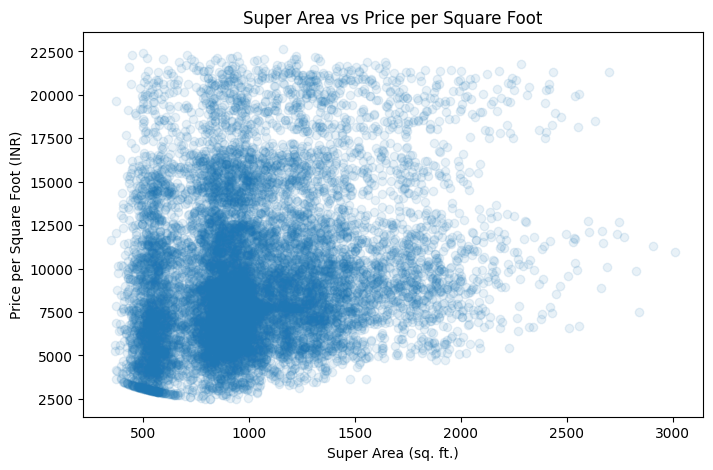

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Super_Area_sqft'], df['Price_per_sqft_INR'], alpha=0.1)
plt.xlabel('Super Area (sq. ft.)')
plt.ylabel('Price per Square Foot (INR)')
plt.title('Super Area vs Price per Square Foot')
plt.show()

Observation: The scatter plot shows a widely dispersed relationship between super area and price per square foot. Although some patterns are visible, super area alone does not appear to determine the price per square foot, indicating that other property and location-related factors also influence house prices.

7. Property Age vs Average Price

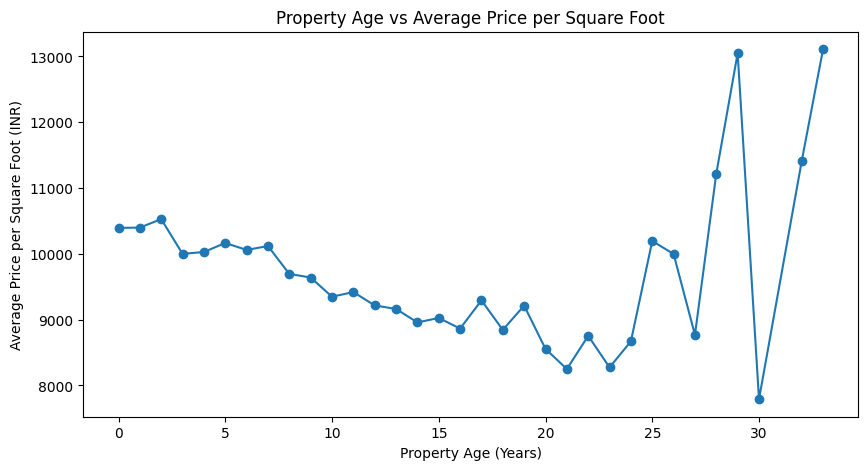

In [ ]:
average_price_age = df.groupby('Property_Age_years')['Price_per_sqft_INR'].mean()

plt.figure(figsize=(10, 5))
plt.plot(average_price_age.index, average_price_age.values, marker='o')
plt.xlabel('Property Age (Years)')
plt.ylabel('Average Price per Square Foot (INR)')
plt.title('Property Age vs Average Price per Square Foot')
plt.show()

Observation: The average price per square foot generally decreases as property age increases up to around 20 years. However, prices fluctuate significantly for older properties, suggesting that property age alone does not determine the price and other factors may also influence it.

8. Furnishing Status vs Average Price

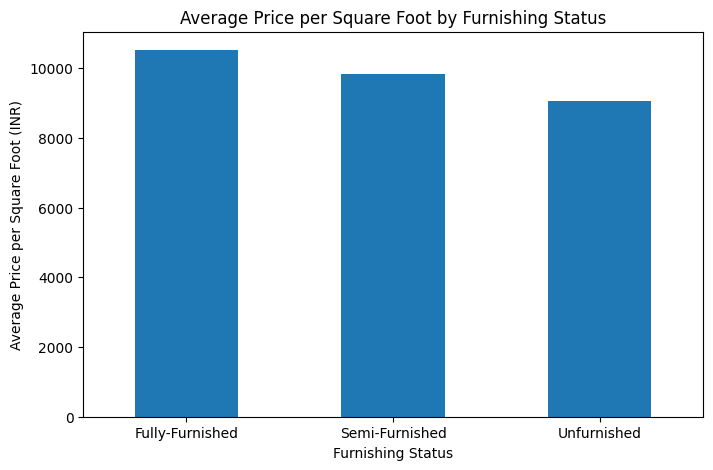

In [ ]:
average_price_furnishing = df.groupby('Furnishing')['Price_per_sqft_INR'].mean()

plt.figure(figsize=(8, 5))
average_price_furnishing.plot(kind='bar')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price per Square Foot (INR)')
plt.title('Average Price per Square Foot by Furnishing Status')
plt.xticks(rotation=0)
plt.show()

Observation: Fully furnished properties have the highest average price per square foot, followed by semi-furnished and unfurnished properties. This suggests that furnishing status influences property prices.

Summary of EDA Insights

The Exploratory Data Analysis provided several important insights into the house price dataset. Most properties have a price per square foot between ₹5,000 and ₹12,000, with the price distribution being positively skewed. Mumbai has the highest number of properties as well as the highest average price per square foot among the cities in the dataset.

The majority of properties are 2 BHK and 3 BHK, while 5 BHK properties are relatively less common. The average price per square foot generally increases with the number of BHKs. Super area alone does not show a strong relationship with price per square foot, indicating that house prices depend on multiple factors.

Property prices generally decrease with property age, although fluctuations are observed among older properties. Furnishing status also influences property prices, with fully furnished properties having the highest average price per square foot, followed by semi-furnished and unfurnished properties.

Overall, the analysis indicates that factors such as city, BHK, property age, furnishing status, and other property characteristics may play an important role in house price prediction.

After cleaning the dataset, the next step is to prepare it for machine learning. This includes separating the target variable, encoding categorical features, splitting the dataset into training and testing sets, and scaling the features. These steps ensure that the data is in the correct format for model training.

Separation of Features and Target

In [33]:

X = df.drop(["House_ID", "Market_Price_INR", "Price_per_sqft_INR"],axis=1)
y = df["Market_Price_INR"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (12000, 18)
Target shape: (12000,)


Converting Text Columns Into Numerical Columns


In [34]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (12000, 23)


,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,...,Nearby_Hospital_km,Crime_Rate_Index,City_Hyderabad,City_Mumbai,City_Nagpur,City_Pune,Locality_Tier_Mid,Locality_Tier_Premium,Furnishing_Semi-Furnished,Furnishing_Unfurnished
0,3,4,957.3,809.1,11,15,8,1,1,0,...,3.52,32.4,True,False,False,False,True,False,True,False
1,2,3,883.3,711.7,13,16,13,1,1,0,...,4.86,66.3,False,False,False,False,False,False,True,False
2,3,4,1331.5,1087.1,13,15,7,1,1,1,...,1.75,23.3,False,False,False,True,False,True,False,True
3,3,4,997.6,801.0,7,19,10,1,1,1,...,0.61,18.8,False,True,False,False,False,True,True,False
4,2,2,967.6,707.6,5,16,6,1,1,1,...,3.93,41.0,False,False,False,True,True,False,False,True


In [35]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)
print("Feature columns saved successfully!")

Feature columns saved successfully!


Splitting the Dataset Into Training and Testing Sets

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)
print(f"Training Data: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing Data: {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

Training Features: (9600, 23)
Testing Features : (2400, 23)
Training Target  : (9600,)
Testing Target   : (2400,)
Training Data: 9600 samples (80%)
Testing Data: 2400 samples (20%)


Feature Scaling


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape :", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled Training Data Shape: (9600, 23)
Scaled Testing Data Shape : (2400, 23)


Verification


In [38]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

X_train_scaled: (9600, 23)
X_test_scaled : (2400, 23)
y_train       : (9600,)
y_test        : (2400,)


Conclusion

The dataset has been successfully prepared for machine learning by:

- Separating input features and target variable.
- Encoding categorical variables.
- Splitting the data into training and testing sets.
- Standardizing the feature values.

The processed dataset is now ready for training machine learning models.

# Machine Learning Model Training

In this section, different machine learning regression models are trained to predict the `Market_Price_INR` of houses. The models use the preprocessed training data and generate predictions on the test dataset.

In [39]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
lr_predictions = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [40]:
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Generate predictions
dt_predictions = dt_model.predict(X_test_scaled)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [41]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Generate predictions
rf_predictions = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [42]:
from sklearn.neighbors import KNeighborsRegressor

# Create the KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
knn_predictions = knn_model.predict(X_test_scaled)

print("KNN model trained successfully!")

KNN model trained successfully!


In [43]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [44]:
print("Prediction shapes:")
print("Linear Regression:", lr_predictions.shape)
print("Decision Tree:", dt_predictions.shape)
print("Random Forest:", rf_predictions.shape)
print("KNN:", knn_predictions.shape)
print("XGBOOST:", xgb_predictions.shape)

Prediction shapes:
Linear Regression: (2400,)
Decision Tree: (2400,)
Random Forest: (2400,)
KNN: (2400,)
XGBOOST: (2400,)


# Model Training Summary

Four machine learning models were trained to predict house market prices:

- Linear Regression
- Decision Tree
- Random Forest
- KNN

All four models successfully generated predictions for the test data. These predictions will be evaluated using different performance metrics in the next step.

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np

In [46]:
def evaluate_model(y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)

    mse = mean_squared_error(y_true, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, predictions)

    return mae, rmse, r2

In [47]:
lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    lr_predictions
)

dt_mae, dt_rmse, dt_r2 = evaluate_model(
    y_test,
    dt_predictions
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_predictions
)

knn_mae, knn_rmse, knn_r2 = evaluate_model(
    y_test,
    knn_predictions
)

xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    y_test,
    xgb_predictions
)

In [49]:
results = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "KNN",

        "XGBoost"

    ],

    "MAE": [

        lr_mae,

        dt_mae,

        rf_mae,

        knn_mae,

        xgb_mae

    ],

    "RMSE": [

        lr_rmse,

        dt_rmse,

        rf_rmse,

        knn_rmse,

        xgb_rmse

    ],

    "R² Score": [

        lr_r2,

        dt_r2,

        rf_r2,

        knn_r2,

        xgb_r2

    ]

})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.327363e+06,1.939827e+06,0.915193
1,Decision Tree,8.002817e+05,1.104599e+06,0.972501
2,Random Forest,5.888478e+05,8.113300e+05,0.985165
3,KNN,1.134767e+06,1.593326e+06,0.942784
4,XGBoost,5.397775e+05,7.622584e+05,0.986905


In [20]:
results = results.sort_values(
    by="RMSE"
)

results

,Model,MAE,RMSE,R² Score
4,XGBoost,1.051162e+05,1.909806e+05,0.999178
2,Random Forest,8.050982e+04,1.934888e+05,0.999156
1,Decision Tree,2.098017e+05,4.104289e+05,0.996204
3,KNN,1.116166e+06,1.536666e+06,0.946781
0,Linear Regression,1.106698e+06,1.719597e+06,0.933356


In [50]:
best_model = results.iloc[0]["Model"]

print("Best Model:", best_model)

Best Model: Linear Regression


In [51]:
results.to_csv(
    "Model_Comparison.csv",
    index=False
)

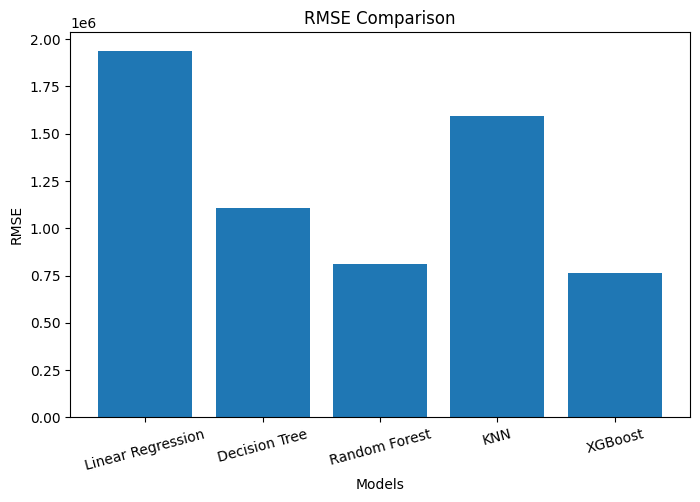

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("RMSE Comparison")

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

for rmse comparison:lower the height of the bar, better result

In [53]:
import joblib
joblib.dump(xgb_model, "house_price_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [54]:
from google.colab import files

files.download("house_price_model.pkl")
files.download("feature_columns.pkl")

files.download("Model_Comparison.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
X.columns.tolist()


['BHK',
 'Bathrooms',
 'Super_Area_sqft',
 'Carpet_Area_sqft',
 'Floor_No',
 'Total_Floors',
 'Property_Age_years',
 'Parking',
 'Lift',
 'Gated_Society',
 'Distance_to_Metro_km',
 'Distance_to_CityCenter_km',
 'Nearby_School_km',
 'Nearby_Hospital_km',
 'Crime_Rate_Index',
 'City_Hyderabad',
 'City_Mumbai',
 'City_Nagpur',
 'City_Pune',
 'Locality_Tier_Mid',
 'Locality_Tier_Premium',
 'Furnishing_Semi-Furnished',
 'Furnishing_Unfurnished']